In [129]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\eyesa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Loading Dataset

In [130]:
df = pd.read_csv("amazon_alexa.tsv", sep="\t")
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [131]:
df.shape

(3150, 5)

In [132]:
df.columns

Index(['rating', 'date', 'variation', 'verified_reviews', 'feedback'], dtype='object')

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3150 entries, 0 to 3149
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   rating            3150 non-null   int64 
 1   date              3150 non-null   object
 2   variation         3150 non-null   object
 3   verified_reviews  3149 non-null   object
 4   feedback          3150 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 123.2+ KB


## Data Cleaning

In [134]:
df.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64

In [135]:
df = df.dropna(subset=['verified_reviews']).reset_index(drop=True)

In [136]:
df.isnull().sum()

rating              0
date                0
variation           0
verified_reviews    0
feedback            0
dtype: int64

In [137]:
df.describe()

,rating,feedback
count,3149.000000,3149.000000
mean,4.463957,0.918704
std,1.067773,0.273332
min,1.000000,0.000000
25%,4.000000,1.000000
50%,5.000000,1.000000
75%,5.000000,1.000000
max,5.000000,1.000000


In [138]:
df['feedback'].value_counts()

feedback
1    2893
0     256
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

In [139]:
print(f"\nPositive reviews: {(df['feedback'] == 1).sum()} ({(df['feedback'] == 1).mean()*100:.1f}%)")
print(f"Negative reviews: {(df['feedback'] == 0).sum()} ({(df['feedback'] == 0).mean()*100:.1f}%)")


Positive reviews: 2893 (91.9%)
Negative reviews: 256 (8.1%)


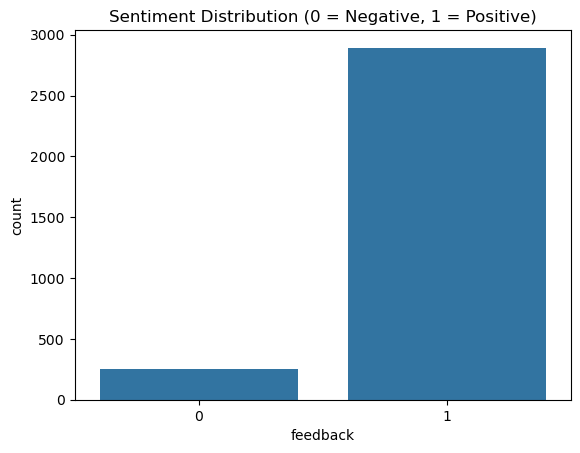

In [140]:
sns.countplot(x='feedback', data=df)
plt.title("Sentiment Distribution (0 = Negative, 1 = Positive)")
plt.show()

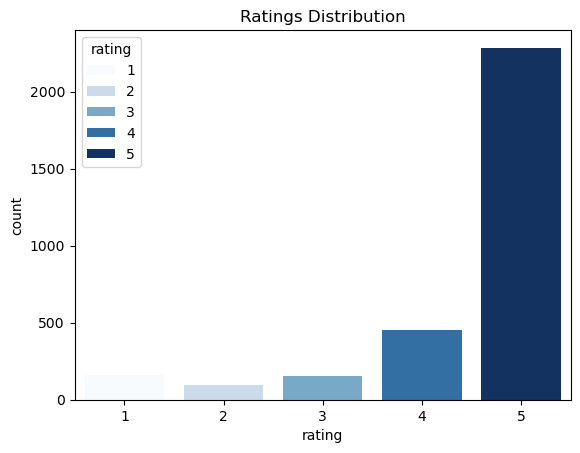

In [141]:
#Rating Distribution 
sns.countplot(x='rating',hue='rating', data=df, palette='Blues')
plt.title("Ratings Distribution")
plt.show()

In [142]:
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

In [143]:
corpus =[]
for review in df['verified_reviews']:
    review = re.sub('[^a-zA-Z]', ' ', review)   # remove symbols
    review = review.lower()                     # lowercase
    review = review.split()
    
    review = [word for word in review if word not in stopwords.words('english')]
    review = ' '.join(review)
    
    corpus.append(review)

In [144]:
print(corpus[:3]) 

['love echo', 'loved', 'sometimes playing game answer question correctly alexa says got wrong answers like able turn lights away home']


In [145]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [146]:
vectorizer = TfidfVectorizer(max_features=2500, ngram_range=(1, 2))
X = vectorizer.fit_transform(corpus).toarray()
y = df['feedback']

In [147]:
print(f"Feature matrix shape: {X.shape}")
print(f"Total reviews: {X.shape[0]}, Features (words/phrases): {X.shape[1]}")

Feature matrix shape: (3149, 2500)
Total reviews: 3149, Features (words/phrases): 2500


## Model Training

In [148]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=50)

In [149]:
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")

Training set: 2204 samples
Test set:     945 samples


In [150]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

## Model Evaluation

In [151]:
y_pred = model.predict(X_test)

In [152]:
from sklearn.metrics import accuracy_score, confusion_matrix

Accuracy =  accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print ("Accuracy: ", Accuracy)

Accuracy:  0.9195767195767196


In [153]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

              precision    recall  f1-score   support

    Negative       0.46      0.66      0.54        68
    Positive       0.97      0.94      0.96       877

    accuracy                           0.92       945
   macro avg       0.72      0.80      0.75       945
weighted avg       0.94      0.92      0.93       945



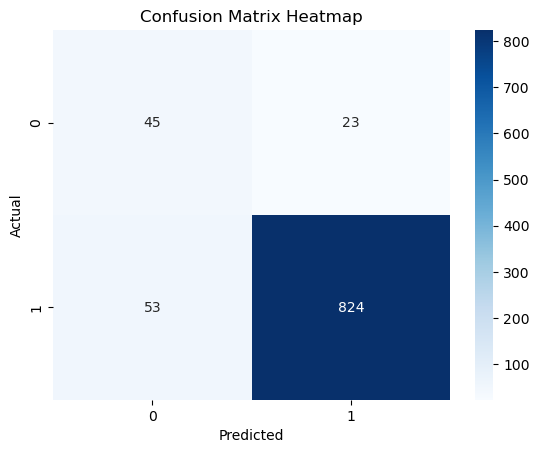

In [154]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Word Cloud Visualization

In [155]:
positive_corpus = [corpus[i] for i in range(len(corpus)) if df['feedback'].iloc[i] == 1]
negative_corpus = [corpus[i] for i in range(len(corpus)) if df['feedback'].iloc[i] == 0]

In [156]:
from wordcloud import WordCloud

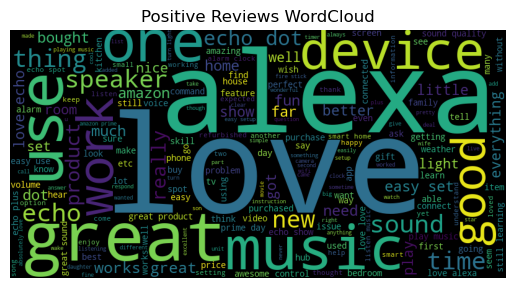

In [157]:
positive_text = " ".join(positive_corpus)
wordcloud = WordCloud(width=800, height=400).generate(positive_text)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Positive Reviews WordCloud")
plt.show()

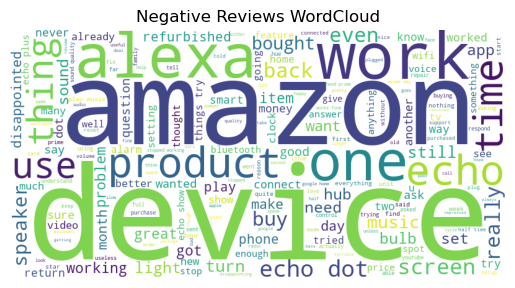

In [158]:
negative_text = " ".join(negative_corpus)

wordcloud_neg = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

plt.imshow(wordcloud_neg)
plt.axis("off")
plt.title("Negative Reviews WordCloud")
plt.show()

## Trying the model

In [159]:
ps = PorterStemmer()
def predict_sentiment(review_text):

    review = re.sub('[^a-zA-Z]', ' ', review_text)
    review = review.lower().split()
    review = [ps.stem(word) for word in review if word not in set(stopwords.words('english'))]
    review = ' '.join(review)

    vector = vectorizer.transform([review]).toarray()
    prediction = model.predict(vector)[0]
    confidence = model.predict_proba(vector)[0][prediction]

    label = "Positive 😊" if prediction == 1 else "Negative 😞"
    print(f"Review:     {review_text}")
    print(f"Sentiment:  {label}")
    print(f"Confidence: {confidence*100:.1f}%")
    print()

# Test with sample reviews
predict_sentiment("I absolutely love this product, it works perfectly!")
predict_sentiment("Terrible product, stopped working after 2 days.")
predict_sentiment("It's okay, not great but does the job.")

Review:     I absolutely love this product, it works perfectly!
Sentiment:  Positive 😊
Confidence: 61.4%

Review:     Terrible product, stopped working after 2 days.
Sentiment:  Negative 😞
Confidence: 79.1%

Review:     It's okay, not great but does the job.
Sentiment:  Positive 😊
Confidence: 83.4%

